# Setup and calibration benchmark

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/BennettHydroLab/differentiable_modeling_workshop/blob/main/notebooks/00_setup_and_motivation.ipynb)

This notebook verifies the environment and calibrates the same six-parameter
rainfall-runoff model with random search and gradient descent. At this scale,
random search is competitive. Gradients become useful when the unknown is a
high-dimensional function rather than a few parameters.

:::{admonition} Time check: 10 minutes
:class: tip
You will write a differentiable conceptual model, use a chronological split,
compare two calibration methods, and batch several basins under one loss.
:::

## Outline

1. Load and inspect a basin
2. Define the HBV-style model
3. Calibrate by random search and gradient descent
4. Compare cost and held-out performance
5. Batch calibration across basins


In [1]:
# --- Colab bootstrap: installs the workshop package on first run -----------
try:
    import workshop_utils
except ImportError:
    %pip install -q "git+https://github.com/BennettHydroLab/differentiable_modeling_workshop.git"
    import workshop_utils

In [2]:
import time

import numpy as np
import torch
import matplotlib.pyplot as plt

from workshop_utils import nse, summary, hydrograph, set_style, COLORS, ParamMap
from workshop_utils.data import (
    load_basin, split_by_water_year, BASIN_TEMPERATE, BASIN_LABELS,
)

set_style()
torch.manual_seed(0)

print(f"torch {torch.__version__}")
print("Setup OK — if this printed, you're ready.")

torch 2.14.0+cu130
Setup OK — if this printed, you're ready.


## 1. Basin data

We'll use `minicamels`: 50 CAMELS-US basins, 30 water years of Daymet forcings
and USGS streamflow, small enough to pull down in a couple of seconds.

Our running example is the Cowpasture River in Virginia: humid, essentially
snow-free, and well behaved. Uncomplicated hydrology keeps the focus on the
method. Later notebooks move to a snow-dominated basin and a semi-arid one,
where things get harder.

In [3]:
ds = load_basin(BASIN_TEMPERATE)

print(BASIN_LABELS[BASIN_TEMPERATE])
print(f"period     : {str(ds.time.values[0])[:10]} to {str(ds.time.values[-1])[:10]}")
print(f"variables  : {list(ds.data_vars)}")
print(f"mean precip: {float(ds.prcp.mean()):.2f} mm/day")
print(f"mean PET   : {float(ds.pet.mean()):.2f} mm/day")
print(f"mean flow  : {float(ds.qobs.mean()):.2f} mm/day")

Cowpasture River, VA (humid temperate)
period     : 1980-10-01 to 2010-09-30
variables  : ['prcp', 'tmax', 'tmin', 'srad', 'vp', 'qobs', 'tmean', 'pet']
mean precip: 3.10 mm/day
mean PET   : 2.57 mm/day
mean flow  : 1.14 mm/day


A note on PET, because it's the first place a hidden assumption could bite you.
CAMELS ships no PET time series, only a long-term mean. `load_basin` computes a
Hamon PET from daily temperature and then rescales it per basin so its
long-term mean matches the CAMELS-reported value. Raw Hamon underestimates that
target by a factor ranging from about 1.2 to 2.2 across the 50 basins, worst in
cold catchments, so a single global correction wouldn't do.

It's a crude PET. It knows nothing about wind, humidity, or vegetation. We're
using it because it needs only what CAMELS gives us, and because calibrated
parameters absorb a lot of PET error. Keep that in mind when you interpret a
calibrated parameter as a physical quantity.

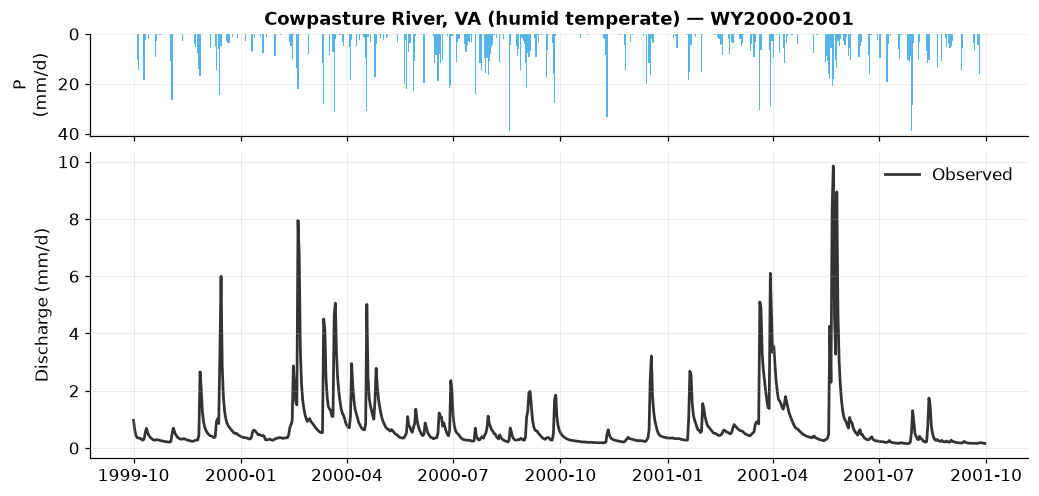

In [4]:
window = slice("1999-10-01", "2001-09-30")
sub = ds.sel(time=window)

hydrograph(
    sub.time.values,
    obs=sub.qobs.values,
    precip=sub.prcp.values,
    title=f"{BASIN_LABELS[BASIN_TEMPERATE]} — WY2000-2001",
)
plt.show()

## 2. HBV-style baseline

Here's an HBV-style conceptual model: one soil-moisture store feeding a fast
and a slow linear reservoir. Six parameters. It is an ordinary conceptual
model, not a machine learning object.

Two details of how it's written matter for what follows:

**Everything is a `torch` operation.** Not numpy. That's what lets PyTorch
record what happened and replay it backwards.

**The parameters carry a leading batch dimension.** `theta` has shape
`(n_parameter_sets, 6)`, and every state variable is a vector rather than a
scalar. The only loop is over time. We cash that in at the end of the notebook,
and it does more work than anything else here.

In the notation used throughout the workshop (see
`resources/research_brief.md`): `u` is the state vector, `x` the forcings,
`theta` the physical parameters.

In [5]:
PARAM_NAMES = ["FC", "beta", "LP", "K_fast", "K_slow", "PERC"]

# Physical bounds. ParamMap squashes an unconstrained real number through a
# sigmoid onto these ranges, so the optimizer gets a free hand while the
# physics never sees a negative field capacity.
LO = torch.tensor([ 50., 1.0, 0.3, 0.05, 0.005, 0.1])
HI = torch.tensor([500., 5.0, 1.0, 0.60, 0.150, 3.0])
pmap = ParamMap(LO, HI)


def simulate(P, E, theta, u0=(50., 5., 20.)):
    """HBV-lite rainfall-runoff.

    P, E   : (time,) precipitation and PET, mm/day
    theta  : (n, 6) parameter sets
    returns: (n, time) simulated discharge, mm/day

    Batched over the leading parameter dimension; the loop is over time only.
    """
    FC, beta, LP, K_fast, K_slow, PERC = theta.T
    n = theta.shape[0]

    # State u = (soil store, fast reservoir, slow reservoir)
    S_soil = torch.full((n,), u0[0])
    S_fast = torch.full((n,), u0[1])
    S_slow = torch.full((n,), u0[2])

    discharge = []
    for t in range(P.shape[0]):
        # Fraction of rainfall that becomes recharge rises nonlinearly with
        # wetness. This is HBV's characteristic beta-curve.
        wetness = torch.clamp(S_soil / FC, 0., 1.)
        recharge = P[t] * wetness ** beta

        # ET shuts down as the soil dries, linearly below a threshold LP*FC.
        et = E[t] * torch.clamp(S_soil / (LP * FC), 0., 1.)
        S_soil = torch.clamp(S_soil + P[t] - recharge - et, min=0.)

        # Percolation moves water from the fast store to the slow one,
        # capped at a constant rate.
        perc = torch.minimum(PERC, S_fast)

        S_fast = S_fast + recharge - perc
        q_fast = K_fast * S_fast
        S_fast = S_fast - q_fast

        S_slow = S_slow + perc
        q_slow = K_slow * S_slow
        S_slow = S_slow - q_slow

        discharge.append(q_fast + q_slow)

    return torch.stack(discharge, dim=1)

### Splitting the data

We split in time, by water year, and we prepend a year of spin-up to each
period.

Both halves of that sentence matter. Adjacent days in a hydrograph are nearly
the same day, so shuffling days into random train and test sets lets the model
memorize its way to a high score; splitting in time is what makes the
evaluation valid. The spin-up year exists because the model starts from a
guessed soil moisture, and you don't want that guess scored. We simulate it and
throw it away.

In [6]:
SPINUP = 365
split = split_by_water_year(ds, train=(1998, 1999), test=(2000, 2002), spinup_days=SPINUP)


def arrays(d):
    return (
        torch.tensor(d.prcp.values, dtype=torch.float32),
        torch.tensor(d.pet.values, dtype=torch.float32),
        torch.tensor(d.qobs.values, dtype=torch.float32),
    )


P, E, Q = arrays(split["train"])
P_test, E_test, Q_test = arrays(split["test"])

print(f"train: {len(P)} days ({SPINUP} of them spin-up)")
print(f"test : {len(P_test)} days ({SPINUP} of them spin-up)")

train: 1095 days (365 of them spin-up)
test : 1461 days (365 of them spin-up)


## 3. Random-search calibration

Throw a few hundred parameter sets at the model and keep the best one. That is
the baseline, and it is what every derivative-free method does underneath, with
a smarter proposal distribution.

The `torch.no_grad()` matters. We're not asking for gradients, so we don't pay
for the graph, and 500 complete three-year simulations run in about a tenth of
a second.

In [7]:
t0 = time.time()

with torch.no_grad():
    raw = torch.randn(500, 6) * 1.5
    sim = simulate(P, E, pmap(raw))
    scores = 1 - ((sim[:, SPINUP:] - Q[SPINUP:]) ** 2).sum(1) / (
        (Q[SPINUP:] - Q[SPINUP:].mean()) ** 2
    ).sum()

t_random = time.time() - t0
best = scores.argmax()

print(f"500 parameter sets in {t_random:.2f} s")
print(f"best NSE   : {scores[best]:.3f}")
print(f"median NSE : {scores.median():.3f}")

500 parameter sets in 0.20 s
best NSE   : 0.643
median NSE : 0.523


## 4. Gradient calibration

Instead of sampling parameter sets, we ask PyTorch which way each parameter
should move to reduce the loss.

Nothing about the model changes. We wrote it in torch operations, so the
gradient is already available and we only have to ask for it. That is all
"differentiable modeling" means at this stage: a hydrologic model whose
derivative we can compute, with no neural network anywhere in it.

In [8]:
t0 = time.time()

raw_g = torch.zeros(1, 6, requires_grad=True)
opt = torch.optim.Adam([raw_g], lr=0.25)

history = []
for step in range(40):
    opt.zero_grad()
    q_sim = simulate(P, E, pmap(raw_g))[0]
    loss = -nse(q_sim[SPINUP:], Q[SPINUP:])   # maximize NSE == minimize -NSE
    loss.backward()
    opt.step()
    history.append(-loss.item())
    if step % 10 == 0:
        print(f"  step {step:3d}   NSE {-loss.item():.3f}")

t_grad = time.time() - t0
theta_cal = pmap(raw_g).detach()

print(f"\n{len(history)} gradient steps in {t_grad:.1f} s ({t_grad/len(history):.2f} s/step)")
print(f"final NSE: {history[-1]:.3f}")

  step   0   NSE 0.614


  step  10   NSE 0.627


  step  20   NSE 0.631


  step  30   NSE 0.634



40 gradient steps in 26.2 s (0.66 s/step)
final NSE: 0.635


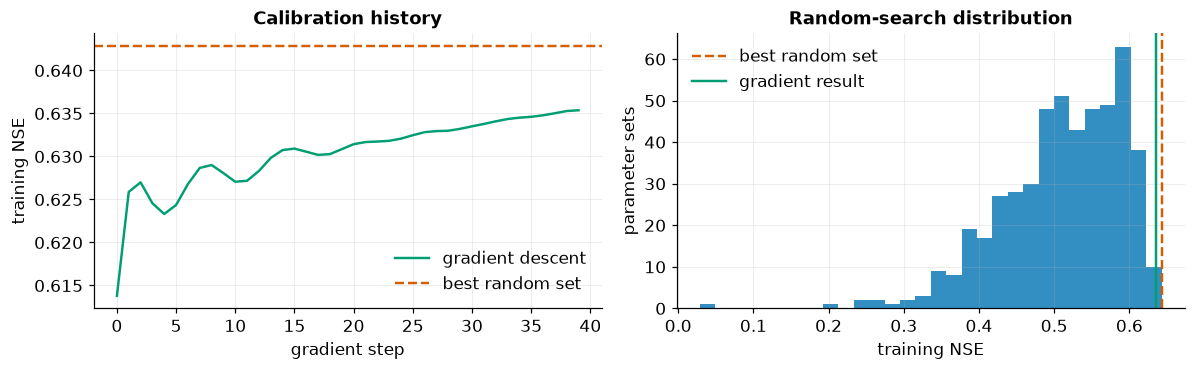

  FC        198.558
  beta        4.560
  LP          0.897
  K_fast      0.322
  K_slow      0.028
  PERC        1.455


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].plot(history, color=COLORS["hybrid"], label="gradient descent")
axes[0].axhline(scores[best], color=COLORS["ml"], ls="--", label="best random set")
axes[0].set(xlabel="gradient step", ylabel="training NSE", title="Calibration history")
axes[0].legend()

axes[1].hist(scores.numpy(), bins=30, color=COLORS["physics"], alpha=0.8)
axes[1].axvline(scores[best], color=COLORS["ml"], ls="--", label="best random set")
axes[1].axvline(history[-1], color=COLORS["hybrid"], label="gradient result")
axes[1].set(xlabel="training NSE", ylabel="parameter sets", title="Random-search distribution")
axes[1].legend()
plt.tight_layout()
plt.show()

for name, value in zip(PARAM_NAMES, theta_cal[0].tolist()):
    print(f"  {name:8s} {value:8.3f}")


Those are physically sensible numbers: a field capacity around 200 mm, a fast
reservoir draining an order of magnitude quicker than the slow one. That is
`ParamMap` doing its job. Whatever the optimizer proposes, the physics only
ever sees a value inside its stated range.

Now score the calibrated model on the held-out years.

Held-out test period (WY2000-2002):
  NSE        0.526
  KGE        0.654
  logNSE     0.283
  PBIAS      7.471
  RMSE       0.717


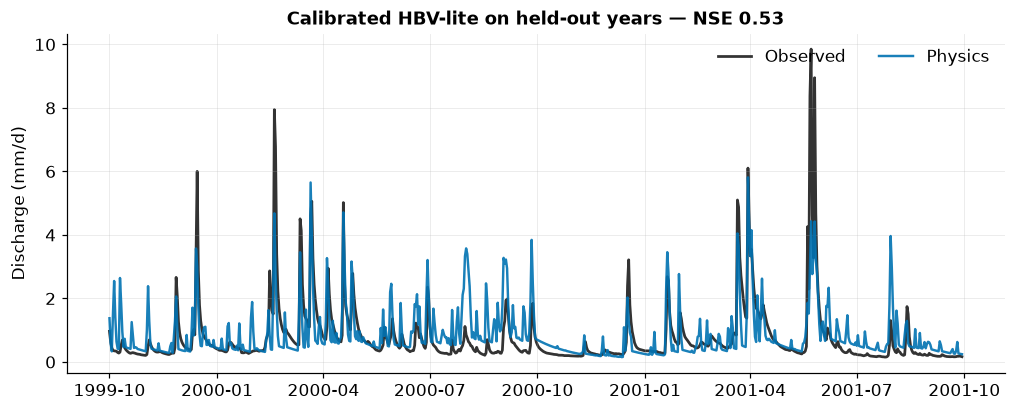

In [10]:
with torch.no_grad():
    q_test = simulate(P_test, E_test, theta_cal)[0]

metrics = summary(q_test[SPINUP:], Q_test[SPINUP:])
print("Held-out test period (WY2000-2002):")
for k, v in metrics.items():
    print(f"  {k:8s} {v:7.3f}")

show = slice(SPINUP, SPINUP + 730)
hydrograph(
    split["test"].time.values[show],
    obs=Q_test[show].numpy(),
    physics=q_test[show].numpy(),
    title=f"Calibrated HBV-lite on held-out years — NSE {metrics['NSE']:.2f}",
)
plt.show()

## 5. Cost comparison

Put the two side by side.

In [11]:
print(f"{'method':<28}{'cost':>10}{'train NSE':>12}")
print("-" * 50)
print(f"{'random search (500 sets)':<28}{t_random:>9.2f}s{scores[best]:>12.3f}")
print(f"{'gradient descent (40 steps)':<28}{t_grad:>9.1f}s{history[-1]:>12.3f}")

method                            cost   train NSE
--------------------------------------------------
random search (500 sets)         0.20s       0.643
gradient descent (40 steps)      26.2s       0.635


Random search is faster here and gives a slightly better training score. A
gradient step must retain and traverse the 1,095-step computation graph, so its
constant cost is high for only six unknowns.

| Parameters | Derivative-free search | Reverse-mode gradient |
|---|---|---|
| 6 | practical | practical, higher overhead |
| 13 | dense grids are impractical | one backward pass |
| 19,208 | impractical | one backward pass |

Reverse-mode cost depends mainly on the executed graph, not the number of
parameters. This is why networks with thousands of weights can be trained
inside a water balance {cite}`shen2023differentiable,lamichhane2025dynamic`.

## 6. Batching across basins

The model already carries a leading batch dimension. The next cell uses that
dimension for 16 basins, with one parameter vector per basin and a shared loss.


In [12]:
from minicamels import MiniCamels

basin_ids = list(MiniCamels().attributes().index)[:16]

cols = [arrays(split_by_water_year(load_basin(b), train=(1998, 1999),
                                   test=(2005, 2005), spinup_days=SPINUP)["train"])
        for b in basin_ids]

P_multi = torch.stack([c[0] for c in cols], dim=1)   # (time, basin)
E_multi = torch.stack([c[1] for c in cols], dim=1)
Q_multi = torch.stack([c[2] for c in cols], dim=1)

print(f"{len(basin_ids)} basins, forcing shape {tuple(P_multi.shape)} (time, basin)")

16 basins, forcing shape (1095, 16) (time, basin)


In [13]:
def simulate_multi(P, E, theta, u0=(50., 5., 20.)):
    """Same model, one parameter vector per basin. P, E: (time, basin)."""
    FC, beta, LP, K_fast, K_slow, PERC = theta.T
    n = theta.shape[0]
    S_soil = torch.full((n,), u0[0])
    S_fast = torch.full((n,), u0[1])
    S_slow = torch.full((n,), u0[2])

    discharge = []
    for t in range(P.shape[0]):
        wetness = torch.clamp(S_soil / FC, 0., 1.)
        recharge = P[t] * wetness ** beta
        et = E[t] * torch.clamp(S_soil / (LP * FC), 0., 1.)
        S_soil = torch.clamp(S_soil + P[t] - recharge - et, min=0.)

        perc = torch.minimum(PERC, S_fast)
        S_fast = S_fast + recharge - perc
        q_fast = K_fast * S_fast
        S_fast = S_fast - q_fast

        S_slow = S_slow + perc
        q_slow = K_slow * S_slow
        S_slow = S_slow - q_slow

        discharge.append(q_fast + q_slow)

    return torch.stack(discharge)     # (time, basin)


t0 = time.time()
raw_m = torch.zeros(16, 6, requires_grad=True)
opt_m = torch.optim.Adam([raw_m], lr=0.25)

for step in range(40):
    opt_m.zero_grad()
    q = simulate_multi(P_multi, E_multi, pmap(raw_m))
    num = ((q[SPINUP:] - Q_multi[SPINUP:]) ** 2).sum(0)
    den = ((Q_multi[SPINUP:] - Q_multi[SPINUP:].mean(0)) ** 2).sum(0)
    loss = (num / den).mean()          # mean of (1 - NSE) across basins
    loss.backward()
    opt_m.step()

t_multi = time.time() - t0

with torch.no_grad():
    q = simulate_multi(P_multi, E_multi, pmap(raw_m))
    num = ((q[SPINUP:] - Q_multi[SPINUP:]) ** 2).sum(0)
    den = ((Q_multi[SPINUP:] - Q_multi[SPINUP:].mean(0)) ** 2).sum(0)
    nse_multi = 1 - num / den

print(f"16 basins, 40 steps : {t_multi:.1f} s ({t_multi/40:.2f} s/step)")
print(f" 1 basin,  40 steps : {t_grad:.1f} s ({t_grad/40:.2f} s/step)")
print(f"\n-> {16}x the work for {t_multi/t_grad:.2f}x the time")
print(f"median NSE across the 16 basins: {nse_multi.median():.3f}")

16 basins, 40 steps : 23.9 s (0.60 s/step)
 1 basin,  40 steps : 26.2 s (0.66 s/step)

-> 16x the work for 0.91x the time
median NSE across the 16 basins: 0.611


Sixteen times the work, and it took no longer than one basin.

The expensive part of a gradient step is the Python loop over 1,095 timesteps
and the autograd graph it builds, and that is paid once no matter how wide the
batch is. Everything inside the loop is a vector operation. Adding basins makes
those vectors longer, which costs almost nothing.

This is what continental-scale differentiable modeling rests on. The cost does
not grow when you add basins, so you can put one model, with one set of shared
weights, across hundreds of catchments and train it under a single loss. When
we get to {cite}`tsai2021calibration` and regionalization in the applications
notebooks, this measurement is why any of it is possible.

## Your turn

Try one of these. Five minutes, and both are a single-line change.

1. Rerun the gradient calibration from a different starting point
   (`raw_g = torch.randn(1, 6) * 0.5` instead of zeros). Does it land on the
   same parameters? On the same NSE? What does the answer tell you about
   equifinality in this model?
2. Swap the basin to `BASIN_ARID` (Cedar Creek, ND, runoff ratio 0.04) and
   recalibrate. How much worse does the model do, and which parameters move?

:::{dropdown} Solution: what you should see
**1.** Across several random starts, this model converges to essentially the
same score, NSE 0.634 to 0.637 from starting points as poor as 0.456. So the
objective is well behaved here. Whether the parameters agree is a separate
question, and you can check it: print `pmap(raw_g)` for each start and compare.
If several distinct parameter sets give you the same NSE, you have
equifinality, and gradients do not fix it. A gradient tells you which way is
downhill, not whether the valley you are in is the only one.
`advanced/06_practical_guide` takes this seriously.

**2.** Much worse: NSE typically drops sharply. A semi-arid basin converts
about 4% of its precipitation to runoff, so the model is being asked to
predict a small residual between two large, uncertain fluxes, and the crude
Hamon PET matters much more. This is a good illustration that a model
structure is fit to a climate as much as to a catchment.
:::

## Takeaways

- Torch operations make the conceptual model differentiable; a neural network
  is not required.
- Random search is competitive for six parameters. Reverse-mode AD is useful
  when the number of unknowns is large.
- Chronological splits, spin-up, and batching determine whether the benchmark
  is meaningful and scalable.
## Where next

Notebook `theory/01_gradients_and_autodiff` examines the gradient calculation.
## References

```{bibliography}
:filter: docname in docnames
```